In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import glob, warnings, gzip, logging, os, sys, csv, re
from math import sin, pi
from scipy.special import erf # Error function 
from lmfit import Parameters, minimize, report_fit
from lmfit.confidence import conf_interval
from math import ceil, sqrt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
from astropy import constants, units
import sys, glob, os, logging, warnings, csv
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter as svg
from astropy.constants import c
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks, fftconvolve
from astropy.stats import sigma_clip
from tqdm import tqdm
from scipy.interpolate import griddata
from astropy import units as u
from astropy.constants import G

#### model

In [2]:
class Model_broad:
    def __init__(self, wave, flux):
        self.x = wave
        self.y = flux

def Broaden(model, vsini, epsilon=0.5, linear=False, findcont=False):
    non_nan_idx = ~np.isnan(model.y)
    wvl = model.x[non_nan_idx]
    flx = model.y[non_nan_idx]
    dwl = wvl[1] - wvl[0]
    binnu = int(np.floor((((vsini/10)/ 299792.458) * max(wvl)) / dwl)) + 1 #adding extra bins for error handling
    #validIndices = np.arange(len(flx)) + binnu => this was used in rotbroad as a user cond ==> this is always on here
    front_fl = np.ones(binnu) * flx[0]
    end_fl = np.ones(binnu) * flx[-1]
    flux = np.concatenate((front_fl, flx, end_fl))
    front_wv = (wvl[0] - (np.arange(binnu) + 1) * dwl)[::-1]
    end_wv = wvl[-1] + (np.arange(binnu) + 1) * dwl
    wave = np.concatenate((front_wv, wvl, end_wv))

    if not linear:
        x = np.logspace(np.log10(wave[0]), np.log10(wave[-1]), len(wave))
    else:
        x = wave
    if findcont:
        model.cont = np.ones_like(flux)  #continuum finding
        
    dx = np.log(x[1] / x[0])
    c = 299792458  #c in m/s
    lim = vsini / c
    if lim < dx:
        warnings.warn("vsini too small ({}). Not broadening!".format(vsini))
        return Model_broad(wave.copy(), flux.copy())      
    d_logx = np.arange(0.0, lim, dx)
    d_logx = np.concatenate((-d_logx[::-1][:-1], d_logx))
    alpha = 1.0 - (d_logx / lim) ** 2
    B = (1.0 - epsilon) * np.sqrt(alpha) + epsilon * np.pi * alpha / 4.0  # epsilon -> limb darkening coeff
    B /= np.sum(B)  # normalize
    broadened = Model_broad(wave.copy(), flux.copy())  # Create a copy of the Model object
    broadened.y = fftconvolve(flux, B, mode='same')
    return broadened

def macro_broaden(xdata, ydata, vmacro):
    c = 299792458 #~constants.c.cgs.value * units.cm.to(units.km)
    sq_pi = np.sqrt(np.pi)
    lambda0 = np.median(xdata)
    xspacing = xdata[1] - xdata[0]
    mr = vmacro * lambda0 / c
    ccr = 2 / (sq_pi * mr)
    px = np.arange(-len(xdata) / 2, len(xdata) / 2 + 1) * xspacing
    pxmr = abs(px) / mr
    profile = ccr * (np.exp(-pxmr ** 2) + sq_pi * pxmr * (erf(pxmr) - 1.0))
    before = ydata[int(-profile.size / 2 + 1):]
    after = ydata[:int(profile.size / 2 +1)] #add one to fix size mismatch
    extended = np.r_[before, ydata, after]
    first = xdata[0] - float(int(profile.size / 2.0 + 0.5)) * xspacing
    last = xdata[-1] + float(int(profile.size / 2.0 + 0.5)) * xspacing
    x2 = np.linspace(first, last, extended.size)  #newdata x array > handles edge effects
    conv_mode = "valid"
    newydata = fftconvolve(extended, profile / profile.sum(), mode=conv_mode)
    return newydata

#### assisting functions


In [3]:
def read_spamms_spectra(infile):
    data = np.loadtxt(infile)
    wave, flux = data[:,0], data[:, 1]
    return wave, flux

def correct_rv(wave, rv=0):
    """
    with the definition; blueshift -> +RV // redshift -> -RV
    replace the - sign with + for blueshift -> -ve RV
    """
    c = 299792.458  # km/s
    return wave / (1 - rv / c)

def read_line_list(filename):
    line_centers = []
    line_ranges = []

    with open(filename, 'r') as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.split(maxsplit=1)
            center = float(parts[0])
            if len(parts) > 1:
                range_str = parts[1].replace('[', '').replace(']', '').replace(',', ' ')
                vals = [float(x) for x in range_str.split()]
                if len(vals) == 2:
                    lambda_min, lambda_max = vals
                else:
                    raise ValueError(f"Invalid range format: {line}")
            else:
                lambda_min, lambda_max = center - 5.0, center + 5.0
            line_centers.append(center)
            line_ranges.append((lambda_min, lambda_max))
    return line_centers, line_ranges

#### fitting structure

In [4]:
def generate_data(wave, flux, line_centers, line_ranges, wavelength_slices):
    interp_func = interp1d(wave,flux,kind="linear", bounds_error=False,fill_value="extrapolate")
    wave_slices = []
    flux_slices = []
    for center, (lambda_min, lambda_max) in zip(line_centers, line_ranges):
        new_wave = np.linspace(lambda_min, lambda_max, wavelength_slices)
        new_flux = interp_func(new_wave)
        wave_slices.append(new_wave)
        flux_slices.append(new_flux)
    return np.concatenate(wave_slices), np.concatenate(flux_slices)

def generate_broaden_from_template(params, template_wave, template_flux,line_centers, line_ranges, wavelength_slices, fit_rotation=False, epsilon=0.5):
    interp_template = interp1d( template_wave, template_flux, kind="linear", bounds_error=False, fill_value="extrapolate")
    model_slices = []
    for i, (center, (lambda_min, lambda_max)) in enumerate(zip(line_centers, line_ranges)):
        wv = np.linspace(lambda_min, lambda_max, wavelength_slices)
        flx = interp_template(wv)
        if fit_rotation:
            broad_rot = Broaden(Model_broad(wv, flx), params["vsini"].value, epsilon=epsilon )
            rot_wave = broad_rot.x
            rot_flux = broad_rot.y
        else:
            rot_wave = wv
            rot_flux = flx
        broad_macro = macro_broaden( rot_wave, rot_flux,  params[f"vmacro{i}"].value)
        interp_macro = interp1d( rot_wave, broad_macro, kind="linear", bounds_error=False, fill_value="extrapolate")
        broad_flux = interp_macro(wv)
        model_slices.append(broad_flux)
    return np.concatenate(model_slices)

def objective_template( params, wave_data, flux_data, template_wave, template_flux, line_centers, line_ranges, wavelength_slices, fit_rotation=False, epsilon=0.5):
    model = generate_broaden_from_template( params=params, template_wave=template_wave, template_flux=template_flux, line_centers=line_centers, line_ranges=line_ranges,
                                            wavelength_slices=wavelength_slices, fit_rotation=fit_rotation, epsilon=epsilon)
    return flux_data - model

In [5]:
def fit_line_from_template( data_wave, data_flux, template_wave, template_flux, line_centers, line_ranges, wavelength_slices=1000, fit_rotation=False,
                            initial_vmacro=50000.0, min_vmacro=0.0, max_vmacro=800000.0, initial_vsini=150000.0, min_vsini=2000.0, max_vsini=400000.0, epsilon=0.5):
    params = Parameters()
    wave_data, flux_data = generate_data( data_wave, data_flux, line_centers, line_ranges, wavelength_slices)
    for i, (center, (lambda_min, lambda_max)) in enumerate(zip(line_centers, line_ranges)):
        params.add(f"vmacro{i}",value=initial_vmacro,min=min_vmacro,max=max_vmacro)
    if fit_rotation:
        params.add("vsini",value=initial_vsini,min=min_vsini,max=max_vsini)
    result = minimize(objective_template,params=params,args=(wave_data,flux_data,template_wave,template_flux,line_centers,line_ranges,wavelength_slices,fit_rotation,epsilon))
    return result

In [26]:
macro_file = "/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/zetaR_zetaT_inc_vcrit_grid/Model_0000/He0.1_CNO7.5/hjd0.00000000000_HEII4200.txt"
rot_file = "/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/pure_rot_inc_vcrit_grid/Model_0000/He0.1_CNO7.5/hjd0.00000000000_HEII4200.txt"
data_wave, data_flux = read_spamms_spectra(macro_file)
template_wave, template_flux = read_spamms_spectra(rot_file)
line_centers = [4200.0]
line_ranges = [(4185.0, 4215.0)]

result = fit_line_from_template(
    data_wave=data_wave,
    data_flux=data_flux,
    template_wave=template_wave,
    template_flux=template_flux,
    line_centers=line_centers,
    line_ranges=line_ranges,
    wavelength_slices=1000,
    fit_rotation=False,  #default
    initial_vmacro=100000.0,
    min_vmacro=0.0,
    max_vmacro=800000.0)

result

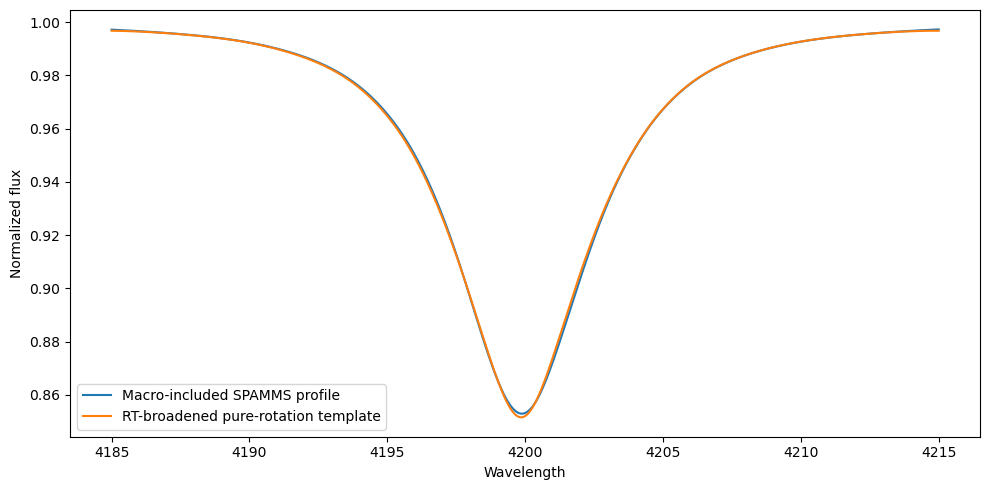

In [27]:
wave_data, flux_data = generate_data(data_wave,data_flux,line_centers,line_ranges,wavelength_slices=1000)
model_flux = generate_broaden_from_template(params=result.params,template_wave=template_wave,template_flux=template_flux,
                                            line_centers=line_centers,line_ranges=line_ranges,wavelength_slices=1000,fit_rotation=False,)

plt.figure(figsize=(10, 5))
plt.plot(wave_data, flux_data, label="Macro-included SPAMMS profile")
plt.plot(wave_data, model_flux, label="RT-broadened pure-rotation template")
plt.xlabel("Wavelength")
plt.ylabel("Normalized flux")
plt.legend()
plt.tight_layout()
plt.show()

#### run for full grid -- helper functions

In [6]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import erf
from scipy.signal import fftconvolve
from scipy.interpolate import interp1d
from lmfit import Parameters, minimize


class Model_broad:
    def __init__(self, wave, flux):
        self.x = wave
        self.y = flux


def Broaden(model, vsini, epsilon=0.5, linear=False, findcont=False):
    non_nan_idx = ~np.isnan(model.y)
    wvl = model.x[non_nan_idx]
    flx = model.y[non_nan_idx]

    dwl = wvl[1] - wvl[0]
    binnu = int(np.floor((((vsini / 10) / 299792.458) * max(wvl)) / dwl)) + 1

    front_fl = np.ones(binnu) * flx[0]
    end_fl = np.ones(binnu) * flx[-1]
    flux = np.concatenate((front_fl, flx, end_fl))

    front_wv = (wvl[0] - (np.arange(binnu) + 1) * dwl)[::-1]
    end_wv = wvl[-1] + (np.arange(binnu) + 1) * dwl
    wave = np.concatenate((front_wv, wvl, end_wv))

    if not linear:
        x = np.logspace(np.log10(wave[0]), np.log10(wave[-1]), len(wave))
    else:
        x = wave

    if findcont:
        model.cont = np.ones_like(flux)

    dx = np.log(x[1] / x[0])
    c = 299792458.0
    lim = vsini / c

    if lim < dx:
        warnings.warn(f"vsini too small ({vsini}). Not broadening!")
        return Model_broad(wave.copy(), flux.copy())

    d_logx = np.arange(0.0, lim, dx)
    d_logx = np.concatenate((-d_logx[::-1][:-1], d_logx))
    alpha = 1.0 - (d_logx / lim) ** 2
    B = (1.0 - epsilon) * np.sqrt(alpha) + epsilon * np.pi * alpha / 4.0
    B /= np.sum(B)

    broadened = Model_broad(wave.copy(), flux.copy())
    broadened.y = fftconvolve(flux, B, mode='same')
    return broadened


def macro_broaden(xdata, ydata, vmacro):
    c = 299792458.0
    sq_pi = np.sqrt(np.pi)
    lambda0 = np.median(xdata)
    xspacing = xdata[1] - xdata[0]
    mr = vmacro * lambda0 / c

    if mr <= 0:
        return ydata.copy()

    ccr = 2.0 / (sq_pi * mr)
    px = np.arange(-len(xdata) / 2, len(xdata) / 2 + 1) * xspacing
    pxmr = np.abs(px) / mr
    profile = ccr * (np.exp(-pxmr ** 2) + sq_pi * pxmr * (erf(pxmr) - 1.0))

    before = ydata[int(-profile.size / 2 + 1):]
    after = ydata[:int(profile.size / 2 + 1)]
    extended = np.r_[before, ydata, after]

    newydata = fftconvolve(extended, profile / profile.sum(), mode='valid')
    return newydata


def read_spamms_spectra(infile):
    data = np.loadtxt(infile)
    return data[:, 0], data[:, 1]


def parse_model_info(info_file):
    params = {}
    with open(info_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or ':' not in line:
                continue
            key, val = line.split(':', 1)
            key, val = key.strip(), val.strip()
            try:
                val = float(val)
            except ValueError:
                pass
            params[key] = val
    return params


def generate_data(wave, flux, line_centers, line_ranges, wavelength_slices):
    interp_func = interp1d(wave, flux, kind='linear', bounds_error=False, fill_value='extrapolate')
    wave_slices, flux_slices = [], []
    for center, (lambda_min, lambda_max) in zip(line_centers, line_ranges):
        new_wave = np.linspace(lambda_min, lambda_max, wavelength_slices)
        new_flux = interp_func(new_wave)
        wave_slices.append(new_wave)
        flux_slices.append(new_flux)
    return np.concatenate(wave_slices), np.concatenate(flux_slices)


def generate_broaden_from_template(params, template_wave, template_flux, line_centers, line_ranges,
                                   wavelength_slices, fit_rotation=False, epsilon=0.5):
    interp_template = interp1d(template_wave, template_flux, kind='linear', bounds_error=False, fill_value='extrapolate')
    model_slices = []

    for i, (center, (lambda_min, lambda_max)) in enumerate(zip(line_centers, line_ranges)):
        wv = np.linspace(lambda_min, lambda_max, wavelength_slices)
        flx = interp_template(wv)

        if fit_rotation:
            broad_rot = Broaden(Model_broad(wv, flx), params['vsini'].value, epsilon=epsilon)
            rot_wave, rot_flux = broad_rot.x, broad_rot.y
        else:
            rot_wave, rot_flux = wv, flx

        broad_macro = macro_broaden(rot_wave, rot_flux, params[f'vmacro{i}'].value)
        interp_macro = interp1d(rot_wave, broad_macro, kind='linear', bounds_error=False, fill_value='extrapolate')
        model_slices.append(interp_macro(wv))

    return np.concatenate(model_slices)


def objective_template(params, wave_data, flux_data, template_wave, template_flux, line_centers,
                       line_ranges, wavelength_slices, fit_rotation=False, epsilon=0.5):
    model = generate_broaden_from_template(params, template_wave, template_flux, line_centers, line_ranges,
                                           wavelength_slices, fit_rotation=fit_rotation, epsilon=epsilon)
    return flux_data - model


def fit_line_from_template(data_wave, data_flux, template_wave, template_flux, line_centers, line_ranges,
                           wavelength_slices=1000, fit_rotation=False, initial_vmacro=50000.0,
                           min_vmacro=0.0, max_vmacro=800000.0, initial_vsini=150000.0,
                           min_vsini=2000.0, max_vsini=400000.0, epsilon=0.5):

    params = Parameters()
    wave_data, flux_data = generate_data(data_wave, data_flux, line_centers, line_ranges, wavelength_slices)

    for i, (center, lr) in enumerate(zip(line_centers, line_ranges)):
        params.add(f'vmacro{i}', value=initial_vmacro, min=min_vmacro, max=max_vmacro)

    if fit_rotation:
        params.add('vsini', value=initial_vsini, min=min_vsini, max=max_vsini)

    result = minimize(objective_template, params=params,
                      args=(wave_data, flux_data, template_wave, template_flux, line_centers,
                            line_ranges, wavelength_slices, fit_rotation, epsilon))
    return result, wave_data, flux_data



In [7]:

def build_rotation_template_dict(rot_root, abundance_folder='He0.1_CNO7.5', line_filename='hjd0.00000000000_HEII4200.txt'):
    rot_dict = {}
    model_dirs = sorted(glob.glob(os.path.join(rot_root, 'Model_*')))

    for model_dir in model_dirs:
        info_file = os.path.join(model_dir, 'model_info.txt')
        profile_file = os.path.join(model_dir, abundance_folder, line_filename)

        if not os.path.exists(info_file) or not os.path.exists(profile_file):
            continue

        params = parse_model_info(info_file)
        inc = float(params['inclination'])
        vcrit = float(params['v_crit_frac'])
        rot_dict[(round(inc, 6), round(vcrit, 6))] = {'profile_path': profile_file, 'params': params}

    return rot_dict


def collect_macro_models(macro_root, abundance_folder='He0.1_CNO7.5', line_filename='hjd0.00000000000_HEII4200.txt'):
    models = []
    model_dirs = sorted(glob.glob(os.path.join(macro_root, 'Model_*')))

    for model_dir in model_dirs:
        info_file = os.path.join(model_dir, 'model_info.txt')
        profile_file = os.path.join(model_dir, abundance_folder, line_filename)

        if not os.path.exists(info_file) or not os.path.exists(profile_file):
            continue

        params = parse_model_info(info_file)
        models.append({'profile_path': profile_file,
                       'run_id': int(params['run_id']),
                       'inclination': float(params['inclination']),
                       'v_crit_frac': float(params['v_crit_frac']),
                       'sigma_R': float(params['sigma_R']),
                       'sigma_T': float(params['sigma_T'])})
    return models


def save_fit_figure(fig_path, wave_data, flux_data, template_wave, template_flux, model_flux,
                    inclination, vcrit, sigma_R, sigma_T, fitted_vmacro_kms,
                    line_center=4200.0, line_range=None):

    plt.figure(figsize=(10, 5))

    plt.plot(template_wave, template_flux, alpha=0.8,
             label='Pure rotation')

    plt.plot(wave_data, flux_data, alpha=0.9,
             label=f'Macro included | sigma_R={sigma_R:.0f}, sigma_T={sigma_T:.0f}')

    plt.plot(wave_data, model_flux, alpha=0.9,
             label=f'RT fit | inc={inclination:.0f}, vcrit={vcrit:.1f}, vmacro={fitted_vmacro_kms:.2f} km/s')

    if line_range is not None:
        plt.xlim(line_range[0], line_range[1])

    plt.xlabel('Wavelength (Å)', fontsize=13)
    plt.ylabel('Normalized flux', fontsize=13)
    plt.tick_params(axis='both', labelsize=11)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.close()


def fit_full_grid_heii4200(macro_root, rot_root, output_csv, fig_dir, abundance_folder='He0.1_CNO7.5',
                           line_filename='hjd0.00000000000_HEII4200.txt', line_center=4200.0,
                           line_range=(4185.0, 4215.0), wavelength_slices=1000,
                           fit_rotation=False, initial_vmacro=50000.0, min_vmacro=0.0,
                           max_vmacro=800000.0, initial_vsini=150000.0, min_vsini=2000.0,
                           max_vsini=400000.0, epsilon=0.5):

    os.makedirs(fig_dir, exist_ok=True)

    line_centers = [line_center]
    line_ranges = [line_range]

    rot_dict = build_rotation_template_dict(rot_root, abundance_folder=abundance_folder, line_filename=line_filename)
    macro_models = collect_macro_models(macro_root, abundance_folder=abundance_folder, line_filename=line_filename)

    rows = []

    for j, model in enumerate(macro_models):
        inc = model['inclination']
        vcrit = model['v_crit_frac']
        sigma_R = model['sigma_R']
        sigma_T = model['sigma_T']
        run_id = model['run_id']
        key = (round(inc, 6), round(vcrit, 6))

        print(f'[{j+1}/{len(macro_models)}] run_id={run_id}, inc={inc}, vcrit={vcrit}, sigma_R={sigma_R}, sigma_T={sigma_T}')

        if key not in rot_dict:
            print(f'  -> No matching pure rotation template found for inc={inc}, vcrit={vcrit}')
            rows.append({'inclination': inc, 'v_crit_frac': vcrit, 'sigma_R': sigma_R, 'sigma_T': sigma_T,
                         'fitted_vmacro': np.nan, 'fitted_vmacro_err': np.nan, 'run_id': run_id})
            continue

        try:
            data_wave, data_flux = read_spamms_spectra(model['profile_path'])
            template_wave, template_flux = read_spamms_spectra(rot_dict[key]['profile_path'])

            result, wave_data, flux_data = fit_line_from_template(
                data_wave=data_wave, data_flux=data_flux, template_wave=template_wave, template_flux=template_flux,
                line_centers=line_centers, line_ranges=line_ranges, wavelength_slices=wavelength_slices,
                fit_rotation=fit_rotation, initial_vmacro=initial_vmacro, min_vmacro=min_vmacro,
                max_vmacro=max_vmacro, initial_vsini=initial_vsini, min_vsini=min_vsini,
                max_vsini=max_vsini, epsilon=epsilon)

            fitted_vmacro = result.params['vmacro0'].value / 1000.0
            fitted_vmacro_err = result.params['vmacro0'].stderr / 1000.0 if result.params['vmacro0'].stderr is not None else np.nan

            model_flux = generate_broaden_from_template(
                params=result.params, template_wave=template_wave, template_flux=template_flux,
                line_centers=line_centers, line_ranges=line_ranges, wavelength_slices=wavelength_slices,
                fit_rotation=fit_rotation, epsilon=epsilon)

            fig_path = os.path.join(fig_dir, f'fit_runid_{run_id:04d}_inc_{int(inc):02d}_vcrit_{vcrit:.1f}_sR_{int(sigma_R):03d}_sT_{int(sigma_T):03d}.png')

            save_fit_figure(fig_path, wave_data, flux_data, template_wave, template_flux, model_flux,
                            inc, vcrit, sigma_R, sigma_T, fitted_vmacro, line_center=line_center, line_range=line_range)

            rows.append({'inclination': inc, 'v_crit_frac': vcrit, 'sigma_R': sigma_R, 'sigma_T': sigma_T,
                         'fitted_vmacro': fitted_vmacro, 'fitted_vmacro_err': fitted_vmacro_err, 'run_id': run_id})

        except Exception as e:
            print(f'  -> Fit failed for run_id={run_id}: {e}')
            rows.append({'inclination': inc, 'v_crit_frac': vcrit, 'sigma_R': sigma_R, 'sigma_T': sigma_T,
                         'fitted_vmacro': np.nan, 'fitted_vmacro_err': np.nan, 'run_id': run_id})

    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    return df

#### .exe

In [ ]:
macro_root = '/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/zetaR_zetaT_inc_vcrit_grid'
rot_root = '/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/pure_rot_inc_vcrit_grid'

output_csv = '/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/heii4200_rt_fit_results.csv'
fig_dir = '/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/heii4200_rt_fit_figures'

df_results = fit_full_grid_heii4200(
    macro_root=macro_root,
    rot_root=rot_root,
    output_csv=output_csv,
    fig_dir=fig_dir,
    line_center=4200.0,
    line_range=(4175.0, 4225.0),
    wavelength_slices=1000,
    fit_rotation=False,
    initial_vmacro=100000.0,   # m/s = 100 km/s
    min_vmacro=0.0,
    max_vmacro=800000.0
)


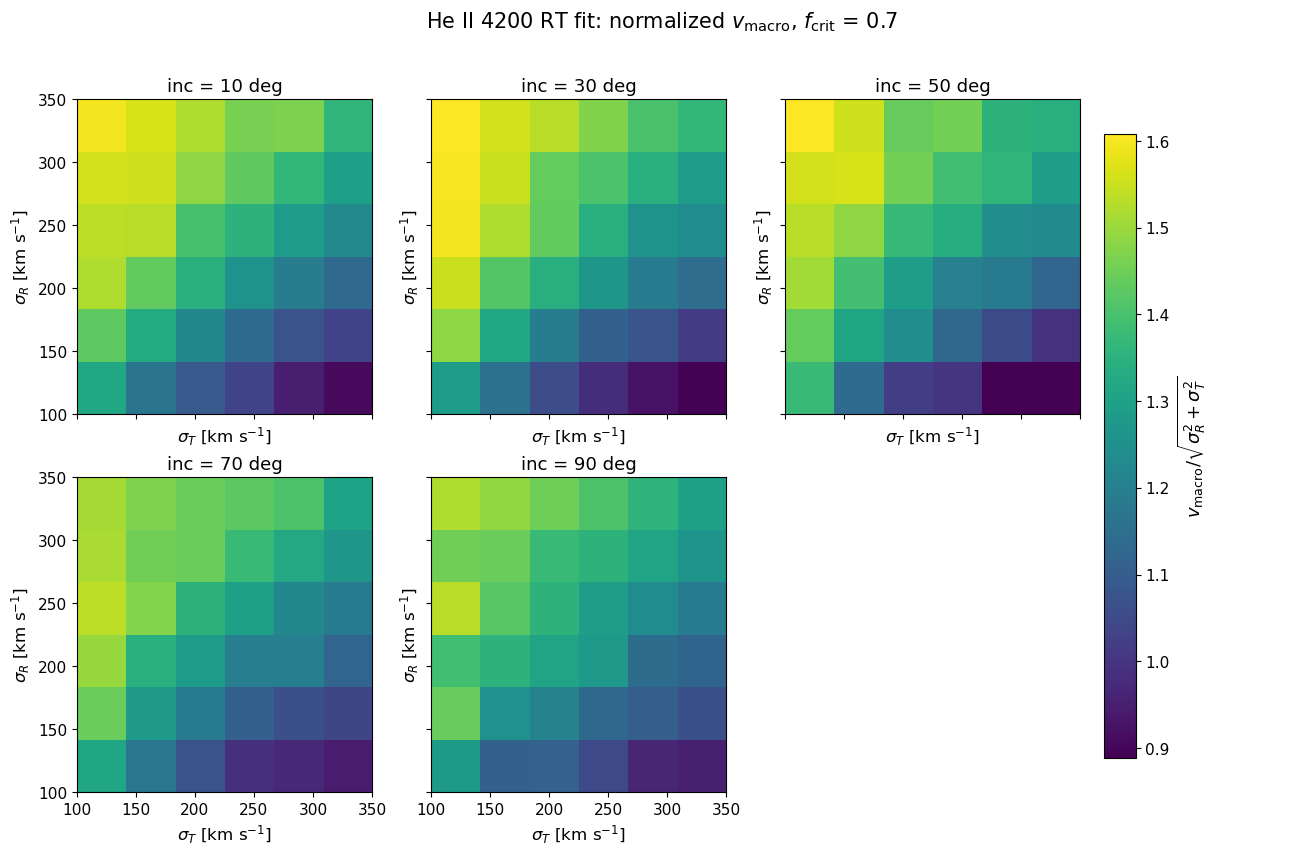

In [46]:
csv_file = '/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/heii4200_rt_fit_results.csv'
df_results = pd.read_csv(csv_file)

vcrit_value = 0.7
df_plot = df_results.copy()
df_plot['vmacro_norm'] = df_plot['fitted_vmacro'] / np.sqrt(df_plot['sigma_R']**2 + df_plot['sigma_T']**2)
d = df_plot[np.isclose(df_plot['v_crit_frac'], vcrit_value)].copy()
inclinations = sorted(d['inclination'].unique())
ncols = 3
nrows = int(np.ceil(len(inclinations) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 4.5*nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
vmin = np.nanmin(d['vmacro_norm'])
vmax = np.nanmax(d['vmacro_norm'])

im = None

for ax, inc in zip(axes, inclinations):
    dd = d[np.isclose(d['inclination'], inc)]

    grid = dd.pivot(index='sigma_R', columns='sigma_T', values='vmacro_norm')
    grid = grid.sort_index().sort_index(axis=1)

    x = grid.columns.values
    y = grid.index.values
    z = grid.values

    im = ax.imshow(z, origin='lower', aspect='auto',
                   extent=[x.min(), x.max(), y.min(), y.max()],
                   vmin=vmin, vmax=vmax, cmap='viridis')

    ax.set_title(f'inc = {inc:.0f} deg', fontsize=13)
    ax.set_xlabel(r'$\sigma_T$ [km s$^{-1}$]', fontsize=12)
    ax.set_ylabel(r'$\sigma_R$ [km s$^{-1}$]', fontsize=12)
    ax.set_xticks(x)
    ax.set_yticks(y)
    ax.tick_params(axis='both', labelsize=11)

for ax in axes[len(inclinations):]:
    ax.axis('off')

cbar = fig.colorbar(im, ax=axes[:len(inclinations)], shrink=0.9, pad=0.02)
cbar.set_label(r'$v_{\rm macro}/\sqrt{\sigma_R^2+\sigma_T^2}$', fontsize=13)
cbar.ax.tick_params(labelsize=11)
fig.suptitle(rf'He II 4200 RT fit: normalized $v_{{\rm macro}}$, $f_{{\rm crit}}$ = {vcrit_value:.1f}', fontsize=15)

'''
if savefig:
    outfile = os.path.join(fig_dir, f'heii4200_vmacro_norm_heatmap_vcrit_{vcrit_value:.1f}.png')
    plt.savefig(outfile, dpi=250, bbox_inches='tight')
    print(f'Saved: {outfile}')
'''
plt.show()

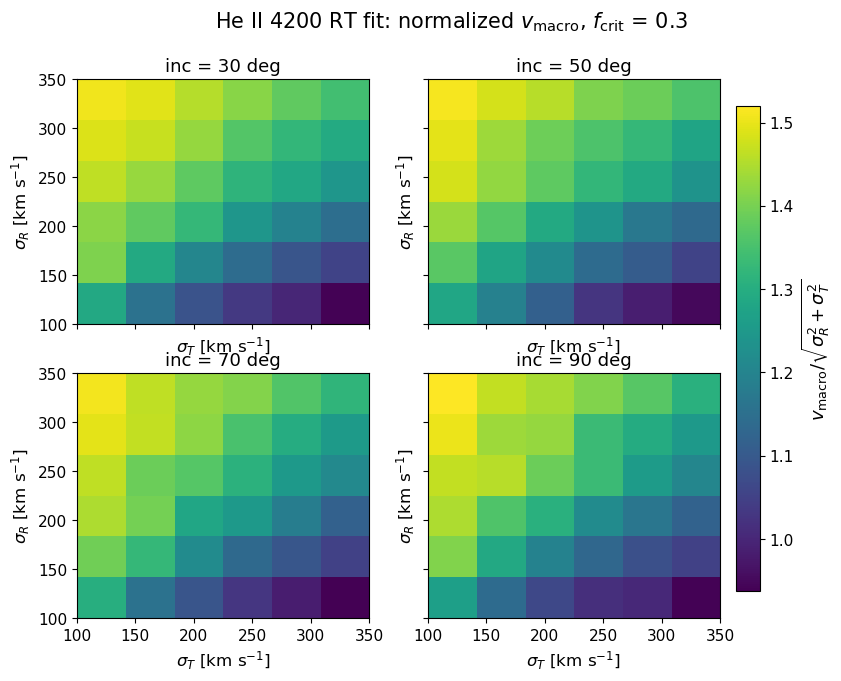

In [7]:
csv_file = '/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/heii4200_rt_fit_results.csv'
df_results = pd.read_csv(csv_file)

vcrit_value = 0.3
inclination_values = [30, 50, 70, 90]

df_plot = df_results.copy()
df_plot['vmacro_norm'] = df_plot['fitted_vmacro'] / np.sqrt(df_plot['sigma_R']**2 + df_plot['sigma_T']**2)

d_all = df_plot[
    np.isclose(df_plot['v_crit_frac'], vcrit_value)
    & df_plot['inclination'].isin(inclination_values)
].copy()

vmin = np.nanmin(d_all['vmacro_norm'])
vmax = np.nanmax(d_all['vmacro_norm'])

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.ravel()

im = None

for ax, inc in zip(axes, inclination_values):
    d = df_plot[
        np.isclose(df_plot['v_crit_frac'], vcrit_value)
        & np.isclose(df_plot['inclination'], inc)
    ].copy()

    grid = d.pivot(index='sigma_R', columns='sigma_T', values='vmacro_norm')
    grid = grid.sort_index().sort_index(axis=1)

    x = grid.columns.values
    y = grid.index.values
    z = grid.values

    im = ax.imshow(z, origin='lower', aspect='auto',
                   extent=[x.min(), x.max(), y.min(), y.max()],
                   vmin=vmin, vmax=vmax, cmap='viridis')

    ax.set_title(f'inc = {inc:.0f} deg', fontsize=13)
    ax.set_xlabel(r'$\sigma_T$ [km s$^{-1}$]', fontsize=12)
    ax.set_ylabel(r'$\sigma_R$ [km s$^{-1}$]', fontsize=12)
    ax.set_xticks(x)
    ax.set_yticks(y)
    ax.tick_params(axis='both', labelsize=11)

cbar = fig.colorbar(im, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label(r'$v_{\rm macro}/\sqrt{\sigma_R^2+\sigma_T^2}$', fontsize=13)
cbar.ax.tick_params(labelsize=11)

fig.suptitle(rf'He II 4200 RT fit: normalized $v_{{\rm macro}}$, $f_{{\rm crit}}$ = {vcrit_value:.1f}', fontsize=15)

#plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.show()